In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [2]:
path="spam/spambase_csv.csv"
df=pd.read_csv(path,encoding="latin-1")

print(df.head())
print(df.tail())
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.info())
print(df.describe(include='all'))
print("\nDuplicate Rows :", df.duplicated().sum())

   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_%3B  char_freq_%28  \
0             0.00            0.00  ...           0.00          0.0

In [3]:
print("\nMissing Values")
missing=pd.DataFrame({"Missing Values": df.isnull().sum(),"Percentage": (df.isnull().sum()/len(df)) * 100})
print(missing)


for col in df.columns:
    if df[col].dtype=="object":
        df[col]=df[col].fillna(df[col].mode()[0])
    else:
        df[col]=df[col].fillna(df[col].median())

print("\nMissing values after preprocessing")
print(df.isnull().sum())


Missing Values
                            Missing Values  Percentage
word_freq_make                           0         0.0
word_freq_address                        0         0.0
word_freq_all                            0         0.0
word_freq_3d                             0         0.0
word_freq_our                            0         0.0
word_freq_over                           0         0.0
word_freq_remove                         0         0.0
word_freq_internet                       0         0.0
word_freq_order                          0         0.0
word_freq_mail                           0         0.0
word_freq_receive                        0         0.0
word_freq_will                           0         0.0
word_freq_people                         0         0.0
word_freq_report                         0         0.0
word_freq_addresses                      0         0.0
word_freq_free                           0         0.0
word_freq_business                       0       

In [4]:
label_encoder=LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = label_encoder.fit_transform(df[col])

print("\nCategorical variables encoded.")
numerical=df.select_dtypes(include=np.number).columns
categorical=df.select_dtypes(exclude=np.number).columns

print("\nNumerical Features")
print(numerical)

print("\nCategorical Features")
print(categorical)


Categorical variables encoded.

Numerical Features
Index(['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_fr

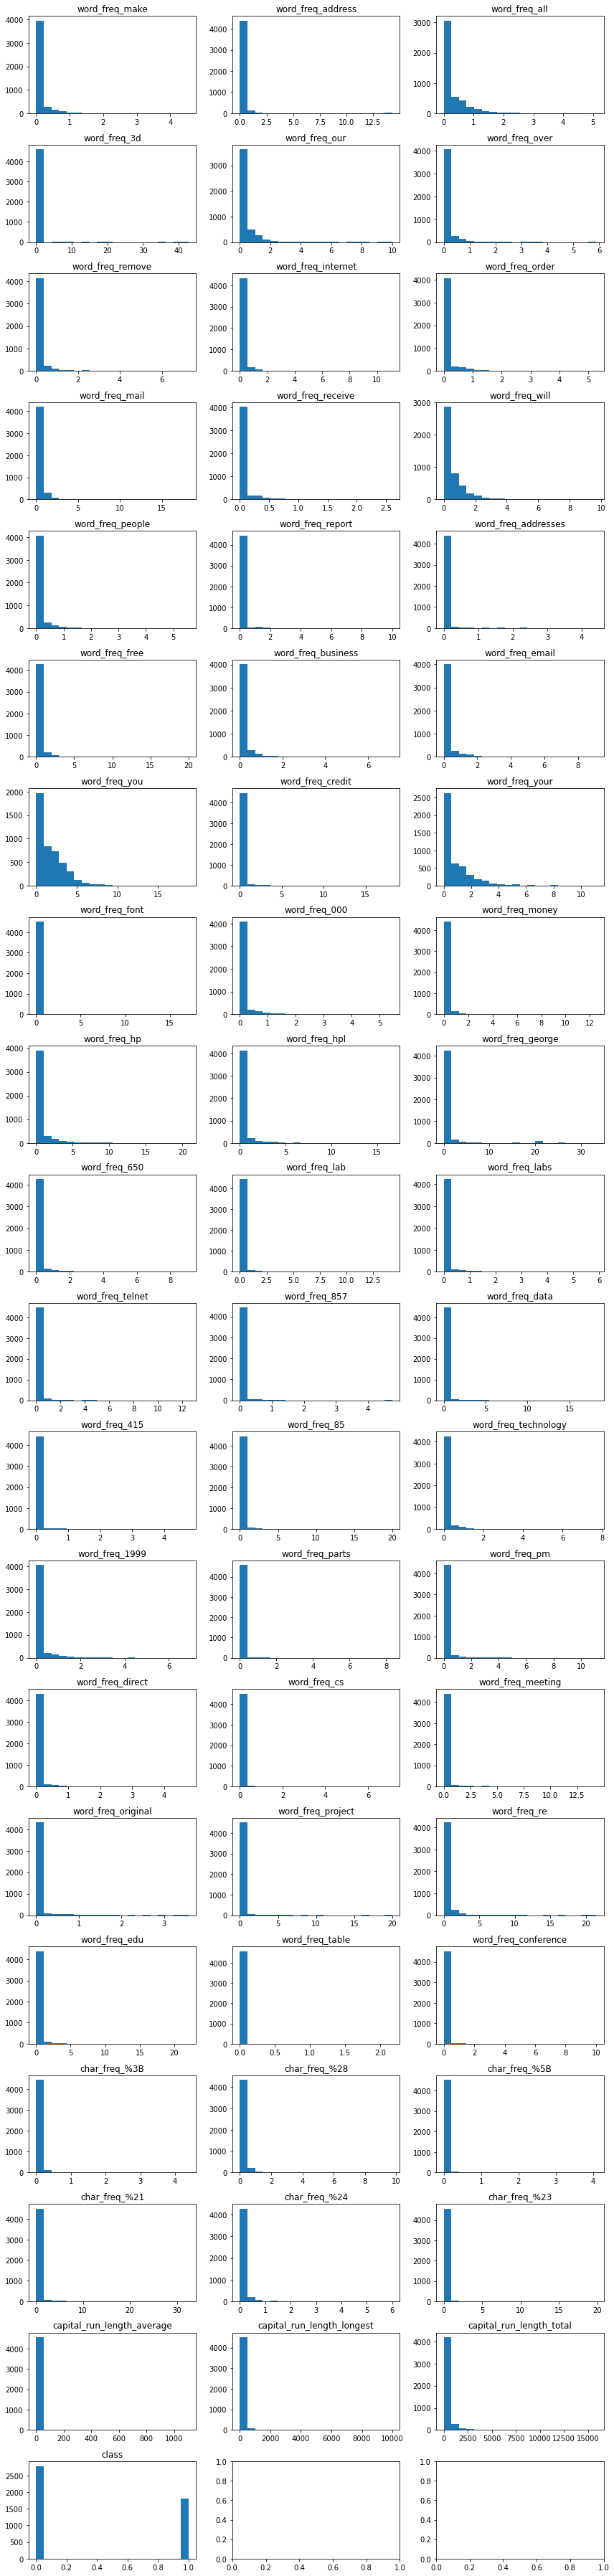

In [27]:
fig, axes = plt.subplots(20, 3, figsize=(12, 50))
axes = axes.flatten()

for i, col in enumerate(numerical):
    axes[i].hist(df[col], bins=20)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

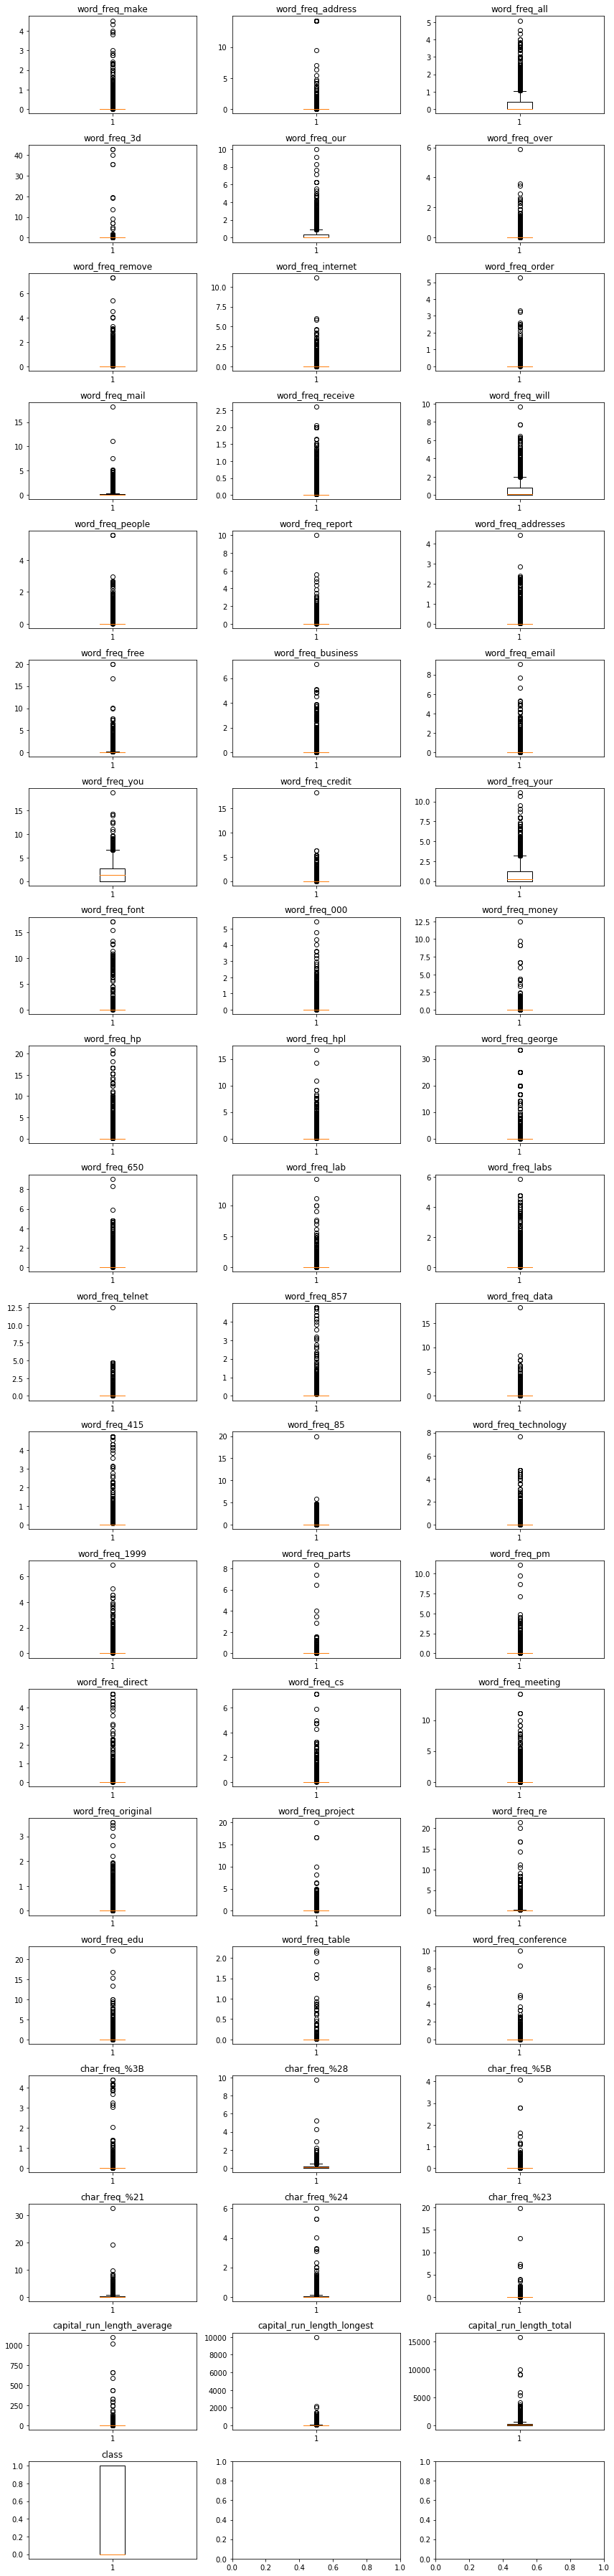

In [28]:
fig, axes = plt.subplots(20, 3, figsize=(12, 50))
axes = axes.flatten()

for i, col in enumerate(numerical):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

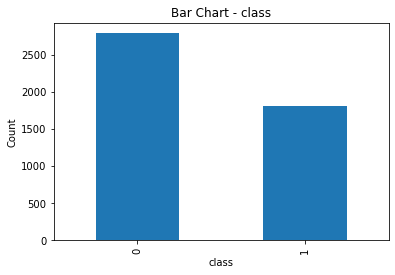

In [29]:
for col in df.columns:
    if df[col].nunique()<=15:
        plt.figure(figsize=(6, 4))
        df[col].value_counts().plot(kind="bar")
        plt.title(f"Bar Chart - {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

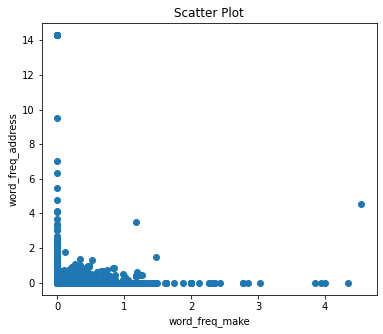

In [30]:
if len(numerical)>=2:
    plt.figure(figsize=(6, 5))
    plt.scatter(df[numerical[0]], df[numerical[1]])
    plt.xlabel(numerical[0])
    plt.ylabel(numerical[1])
    plt.title("Scatter Plot")
    plt.show()

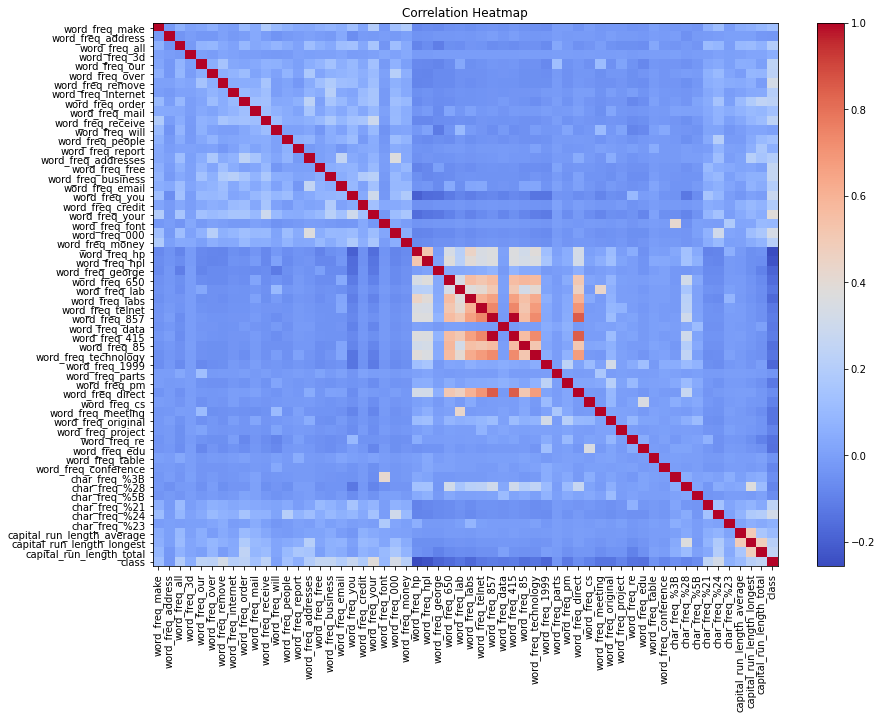

In [33]:
corr=df[numerical].corr()
plt.figure(figsize=(14,10))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

In [51]:
for col in numerical:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    outliers=df[(df[col]<lower)|(df[col]>upper)]
    print(col,"=",len(outliers),"outliers")

v1 = 747 outliers
v2 = 0 outliers
Unnamed: 2 = 47 outliers
Unnamed: 3 = 10 outliers
Unnamed: 4 = 4 outliers


In [52]:
standard_scaler = StandardScaler()
standardized=standard_scaler.fit_transform(df[numerical])
standardized_df=pd.DataFrame(standardized,columns=numerical)
print("\nStandardized Data")
print(standardized_df.head())


Standardized Data
        v1        v2  Unnamed: 2  Unnamed: 3  Unnamed: 4
0 -0.39347 -1.016908   -0.037107   -0.035167    0.024466
1 -0.39347  0.345511   -0.037107   -0.035167    0.024466
2  2.54149 -1.070138   -0.037107   -0.035167    0.024466
3 -0.39347  1.010549   -0.037107   -0.035167    0.024466
4 -0.39347  0.113725   -0.037107   -0.035167    0.024466


In [53]:
minmax = MinMaxScaler()
normalized = minmax.fit_transform(df[numerical])
normalized_df = pd.DataFrame(normalized,columns=numerical)
print("\nNormalised Data")
print(normalized_df.head())


Normalised Data
    v1        v2  Unnamed: 2  Unnamed: 3  Unnamed: 4
0  0.0  0.208785    0.380952    0.111111         1.0
1  0.0  0.600039    0.380952    0.111111         1.0
2  1.0  0.193498    0.380952    0.111111         1.0
3  0.0  0.791022    0.380952    0.111111         1.0
4  0.0  0.533475    0.380952    0.111111         1.0
